# Core Task 1 - T2 Relaxometry QC (Python)

This notebook implements **core task 1** for `T2_MRI_coursework.pdf`:
- inspect acquisition/model-assumption violations before model fitting,
- quantify monotonicity and mono-exponential consistency,
- rank case-level risk and propose fitting-stage mitigations.


## 0) Environment and Setup

Expected environment:
- Python 3.11
- Required: `numpy`, `scipy`, `matplotlib`, `pandas`
- Optional: `nibabel` (if absent, code uses a fallback `.nii.gz` loader based on `gzip+struct`)

If needed in your current kernel, run:
```python
# %pip install numpy scipy matplotlib pandas nibabel
```


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'project3_data0').exists() and (ROOT.parent / 'project3_data0').exists():
    ROOT = ROOT.parent.resolve()

CORE_DIR = ROOT / 'core_task1'
if str(CORE_DIR) not in sys.path:
    sys.path.insert(0, str(CORE_DIR))

from task1_qc import (
    DEFAULT_THRESHOLDS,
    discover_cases,
    load_case,
    audit_case,
    compute_global_decay_profile,
    sample_curves,
    compute_qc_metrics,
    largest_roi_labels,
    make_case_report,
    summarize_case_reports,
    run_synthetic_sanity_checks,
)

SEED = 7
THRESHOLDS = dict(DEFAULT_THRESHOLDS)
THRESHOLDS.update(
    {
        'mono_rel_inc_thresh': 0.05,
        'r2_poor_thresh': 0.95,
        'echo_z_thresh': 2.5,
    }
)

OUTPUT_DIR = ROOT / 'core_task1' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Repository root:', ROOT)
print('Output dir:', OUTPUT_DIR)
print('Thresholds:', THRESHOLDS)


Repository root: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework
Output dir: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework\core_task1\outputs
Thresholds: {'mono_rel_inc_thresh': 0.05, 'early_echo_fraction': 0.5, 'r2_poor_thresh': 0.95, 'echo_z_thresh': 2.5, 'max_voxels_for_r2': 5000, 'eps': 1e-06}


In [2]:
import importlib.util as iu

required = ['numpy', 'scipy', 'matplotlib', 'pandas']
optional = ['nibabel', 'seaborn']
rows = []
for module_name in required + optional:
    rows.append(
        {
            'module': module_name,
            'installed': bool(iu.find_spec(module_name)),
            'required': module_name in required,
        }
    )

deps_df = pd.DataFrame(rows)
display(deps_df)

missing_required = deps_df.query('required and not installed')
if not missing_required.empty:
    raise RuntimeError(f'Missing required dependencies: {missing_required.module.tolist()}')

if bool(iu.find_spec('nibabel')):
    print('nibabel detected: standard NIfTI loading path will be used.')
else:
    print('nibabel not detected: fallback gzip+struct NIfTI loader will be used.')


,module,installed,required
0,numpy,True,True
1,scipy,True,True
2,matplotlib,True,True
3,pandas,True,True
4,nibabel,True,False
5,seaborn,True,False


nibabel detected: standard NIfTI loading path will be used.


## 1) Data Audit

For each case we verify:
- shape consistency (`qt2_reg` 4D vs mask 3D),
- TE consistency (non-decreasing, duplicates),
- basic signal sanity.


In [3]:
cases = discover_cases(ROOT)
if not cases:
    raise RuntimeError(f'No cases found under {ROOT}')

case_data = {}
audit_rows = []
for cp in cases:
    bundle = load_case(cp.case_dir, cp.case_id)
    case_data[cp.case_id] = bundle
    audit_rows.append(audit_case(bundle['data'], bundle['mask'], bundle['tes'], case_id=cp.case_id))

audit_df = pd.DataFrame(audit_rows).sort_values('case_id').reset_index(drop=True)
audit_df


,case_id,shape_xyz_t,mask_shape_xyz,shape_match,time_match,te_count,te_non_decreasing,te_duplicate_count,te_min_step_ms,brain_voxels,finite_data_rate_pct,nonpositive_sample_rate_pct
0,case01,"(96, 96, 55, 19)","(96, 96, 55)",True,True,19,True,0,2.0,109859,100.0,0.002156
1,case02,"(96, 96, 55, 22)","(96, 96, 55)",True,True,22,True,1,0.0,94789,100.0,0.002350
2,case03,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,1.0,61872,100.0,0.053952
3,case04,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,1.0,101592,100.0,0.002812
4,case05,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,1.0,104689,100.0,0.002502
5,case06,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,1.0,90702,100.0,0.011655


In [4]:
audit_cols = [
    'case_id',
    'shape_xyz_t',
    'mask_shape_xyz',
    'shape_match',
    'time_match',
    'te_count',
    'te_non_decreasing',
    'te_duplicate_count',
    'brain_voxels',
    'nonpositive_sample_rate_pct',
]
display(audit_df[audit_cols])

issues = audit_df[
    (~audit_df['shape_match'])
    | (~audit_df['time_match'])
    | (~audit_df['te_non_decreasing'])
    | (audit_df['te_duplicate_count'] > 0)
]

if issues.empty:
    print('No structural/TE audit issues detected.')
else:
    print('Audit issues requiring explicit report discussion:')
    display(issues[['case_id', 'te_count', 'te_non_decreasing', 'te_duplicate_count', 'shape_match', 'time_match']])


,case_id,shape_xyz_t,mask_shape_xyz,shape_match,time_match,te_count,te_non_decreasing,te_duplicate_count,brain_voxels,nonpositive_sample_rate_pct
0,case01,"(96, 96, 55, 19)","(96, 96, 55)",True,True,19,True,0,109859,0.002156
1,case02,"(96, 96, 55, 22)","(96, 96, 55)",True,True,22,True,1,94789,0.002350
2,case03,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,61872,0.053952
3,case04,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,101592,0.002812
4,case05,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,104689,0.002502
5,case06,"(96, 96, 55, 21)","(96, 96, 55)",True,True,21,True,0,90702,0.011655


Audit issues requiring explicit report discussion:


,case_id,te_count,te_non_decreasing,te_duplicate_count,shape_match,time_match
1,case02,22,True,1,True,True


## 2) Global Decay Check

For each case, we plot the brain-mask median signal across TE and flag echo transitions
with large robust z-scores in relative step changes.


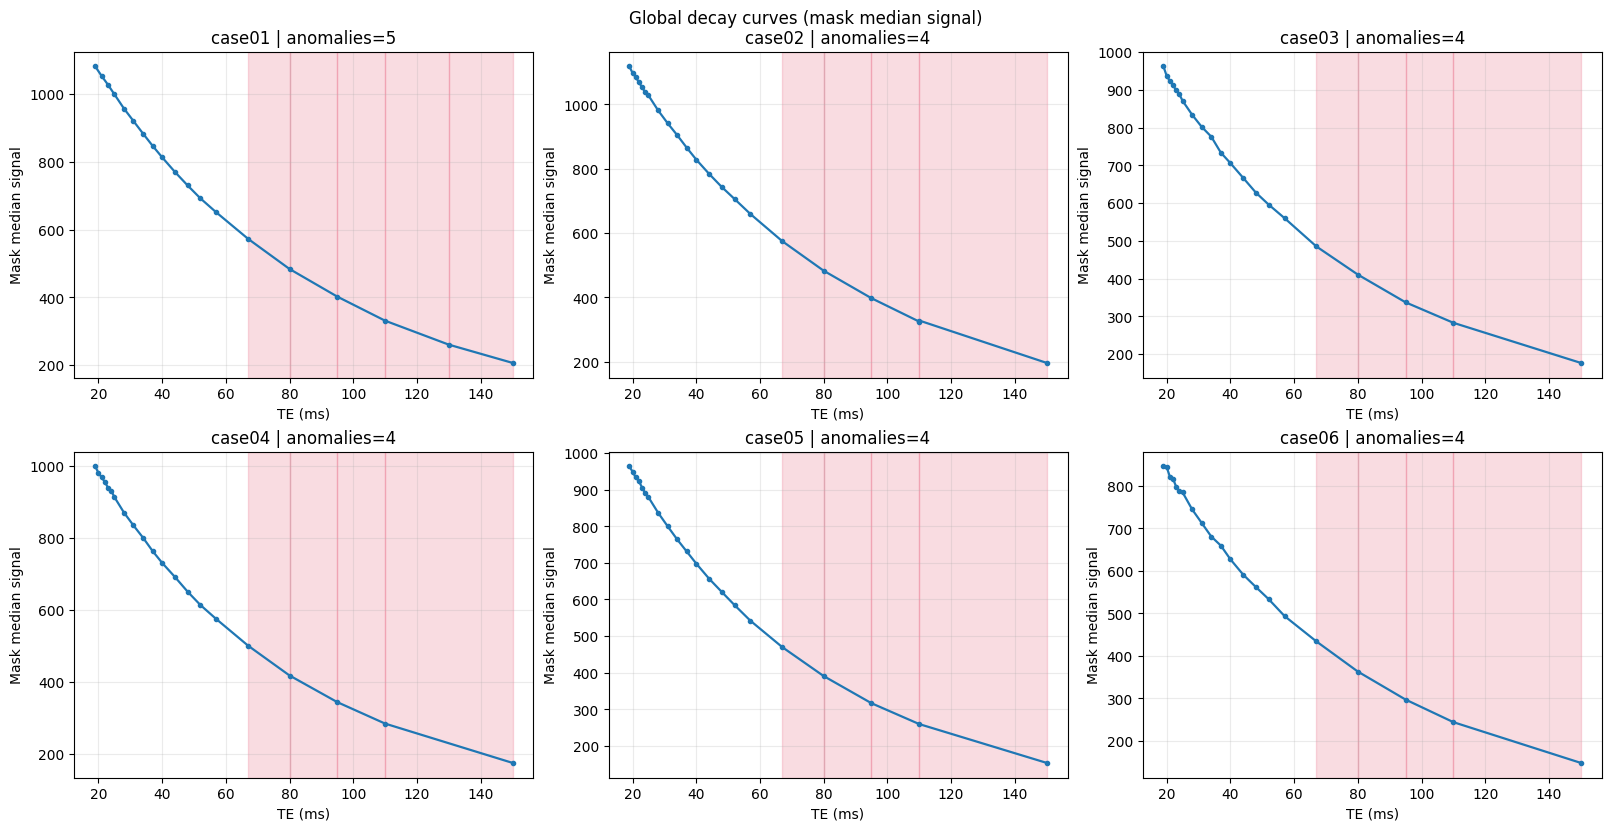

In [5]:
global_profiles = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, cp in zip(axes.ravel(), cases):
    c = case_data[cp.case_id]
    profile = compute_global_decay_profile(
        c['data'],
        c['mask'],
        c['tes'],
        z_thresh=THRESHOLDS['echo_z_thresh'],
        eps=THRESHOLDS['eps'],
    )
    global_profiles[cp.case_id] = profile

    te = c['tes']
    med = profile['median_curve']
    ax.plot(te, med, marker='o', ms=3, lw=1.6)

    for idx in profile['anomaly_indices']:
        ax.axvspan(te[idx], te[idx + 1], color='crimson', alpha=0.15)

    ax.set_title(f"{cp.case_id} | anomalies={len(profile['anomaly_indices'])}")
    ax.set_xlabel('TE (ms)')
    ax.set_ylabel('Mask median signal')
    ax.grid(alpha=0.25)

fig.suptitle('Global decay curves (mask median signal)', y=1.02)
fig.savefig(OUTPUT_DIR / 'global_decay_curves.png', dpi=180)
plt.show()


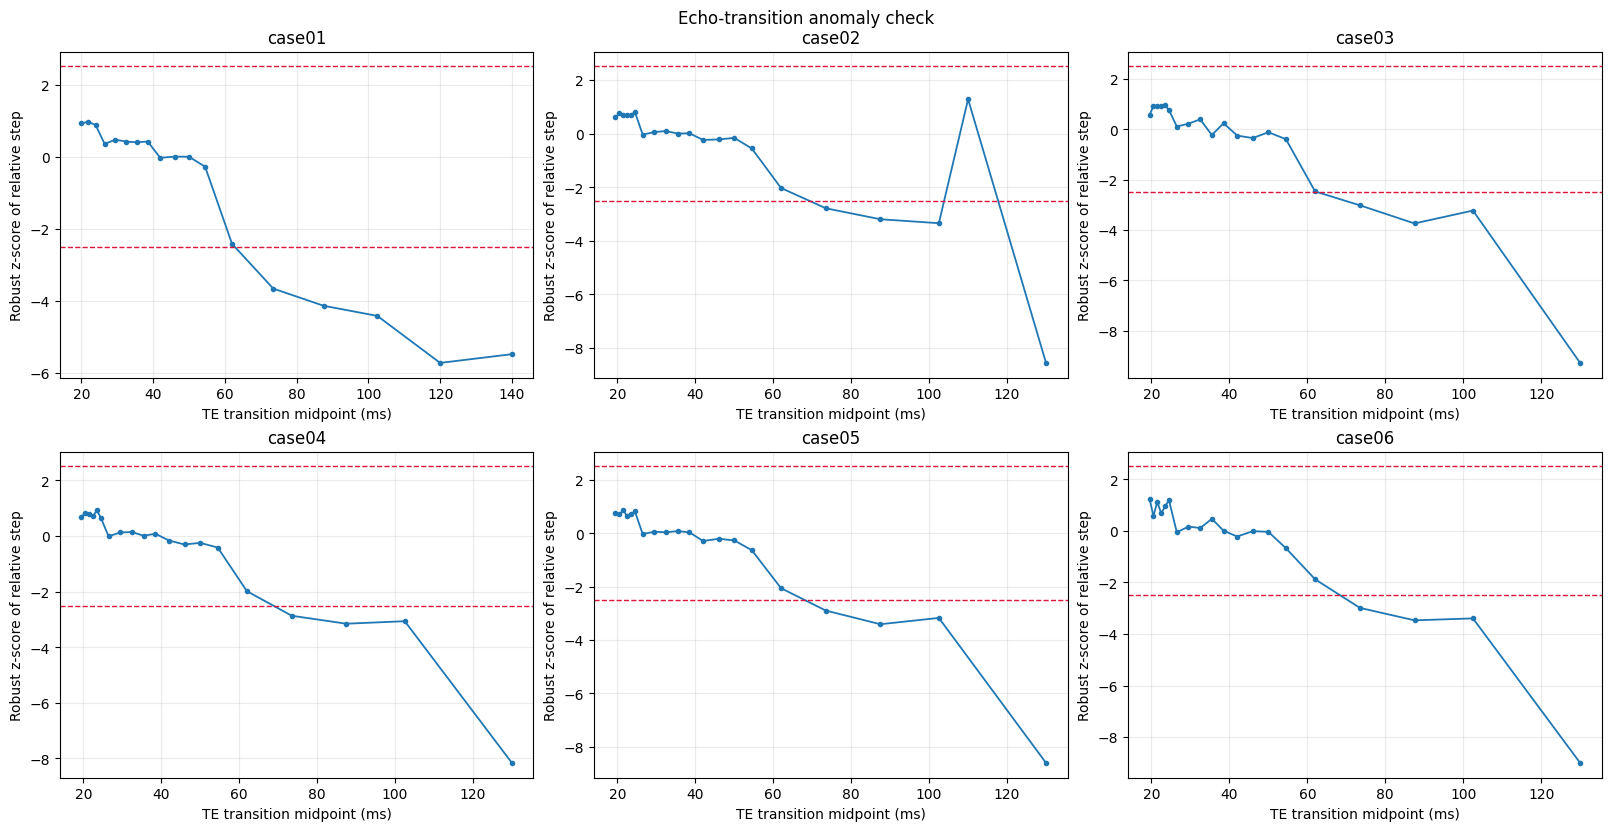

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, cp in zip(axes.ravel(), cases):
    c = case_data[cp.case_id]
    p = global_profiles[cp.case_id]
    te_mid = 0.5 * (c['tes'][:-1] + c['tes'][1:])

    ax.plot(te_mid, p['step_z_scores'], marker='o', ms=3, lw=1.3)
    ax.axhline(THRESHOLDS['echo_z_thresh'], color='crimson', linestyle='--', lw=1)
    ax.axhline(-THRESHOLDS['echo_z_thresh'], color='crimson', linestyle='--', lw=1)
    ax.set_title(cp.case_id)
    ax.set_xlabel('TE transition midpoint (ms)')
    ax.set_ylabel('Robust z-score of relative step')
    ax.grid(alpha=0.25)

fig.suptitle('Echo-transition anomaly check', y=1.02)
fig.savefig(OUTPUT_DIR / 'echo_transition_zscores.png', dpi=180)
plt.show()


## 3) Voxel/ROI Curves

We sample curves from `par_lobe` ROIs (top-3 largest labels in brain mask per case), then plot:
- raw signal vs TE,
- log(signal) vs TE.


In [7]:
curve_frames = []
selected_labels = {}

for cp in cases:
    c = case_data[cp.case_id]
    roi_map = c['par_lobe']
    if roi_map is None:
        continue

    labels = largest_roi_labels(roi_map, c['mask'], top_k=3, min_voxels=1200)
    if not labels:
        labels = largest_roi_labels(roi_map, c['mask'], top_k=3, min_voxels=200)

    selected_labels[cp.case_id] = labels
    sampled = sample_curves(
        c['data'],
        c['mask'],
        roi_map,
        n_per_roi=30,
        seed=SEED,
        tes=c['tes'],
        roi_labels=labels,
    )
    sampled['case_id'] = cp.case_id
    curve_frames.append(sampled)

curves_df = pd.concat(curve_frames, ignore_index=True) if curve_frames else pd.DataFrame()

display(
    pd.DataFrame(
        {
            'case_id': [cp.case_id for cp in cases],
            'roi_labels': [selected_labels.get(cp.case_id, []) for cp in cases],
            'sample_rows': [
                int((curves_df['case_id'] == cp.case_id).sum()) if not curves_df.empty else 0
                for cp in cases
            ],
        }
    )
)


,case_id,roi_labels,sample_rows
0,case01,"[1, 2, 3]",1710
1,case02,"[1, 2, 4]",1980
2,case03,"[1, 2, 4]",1890
3,case04,"[1, 2, 4]",1890
4,case05,"[1, 2, 4]",1890
5,case06,"[2, 1, 4]",1890


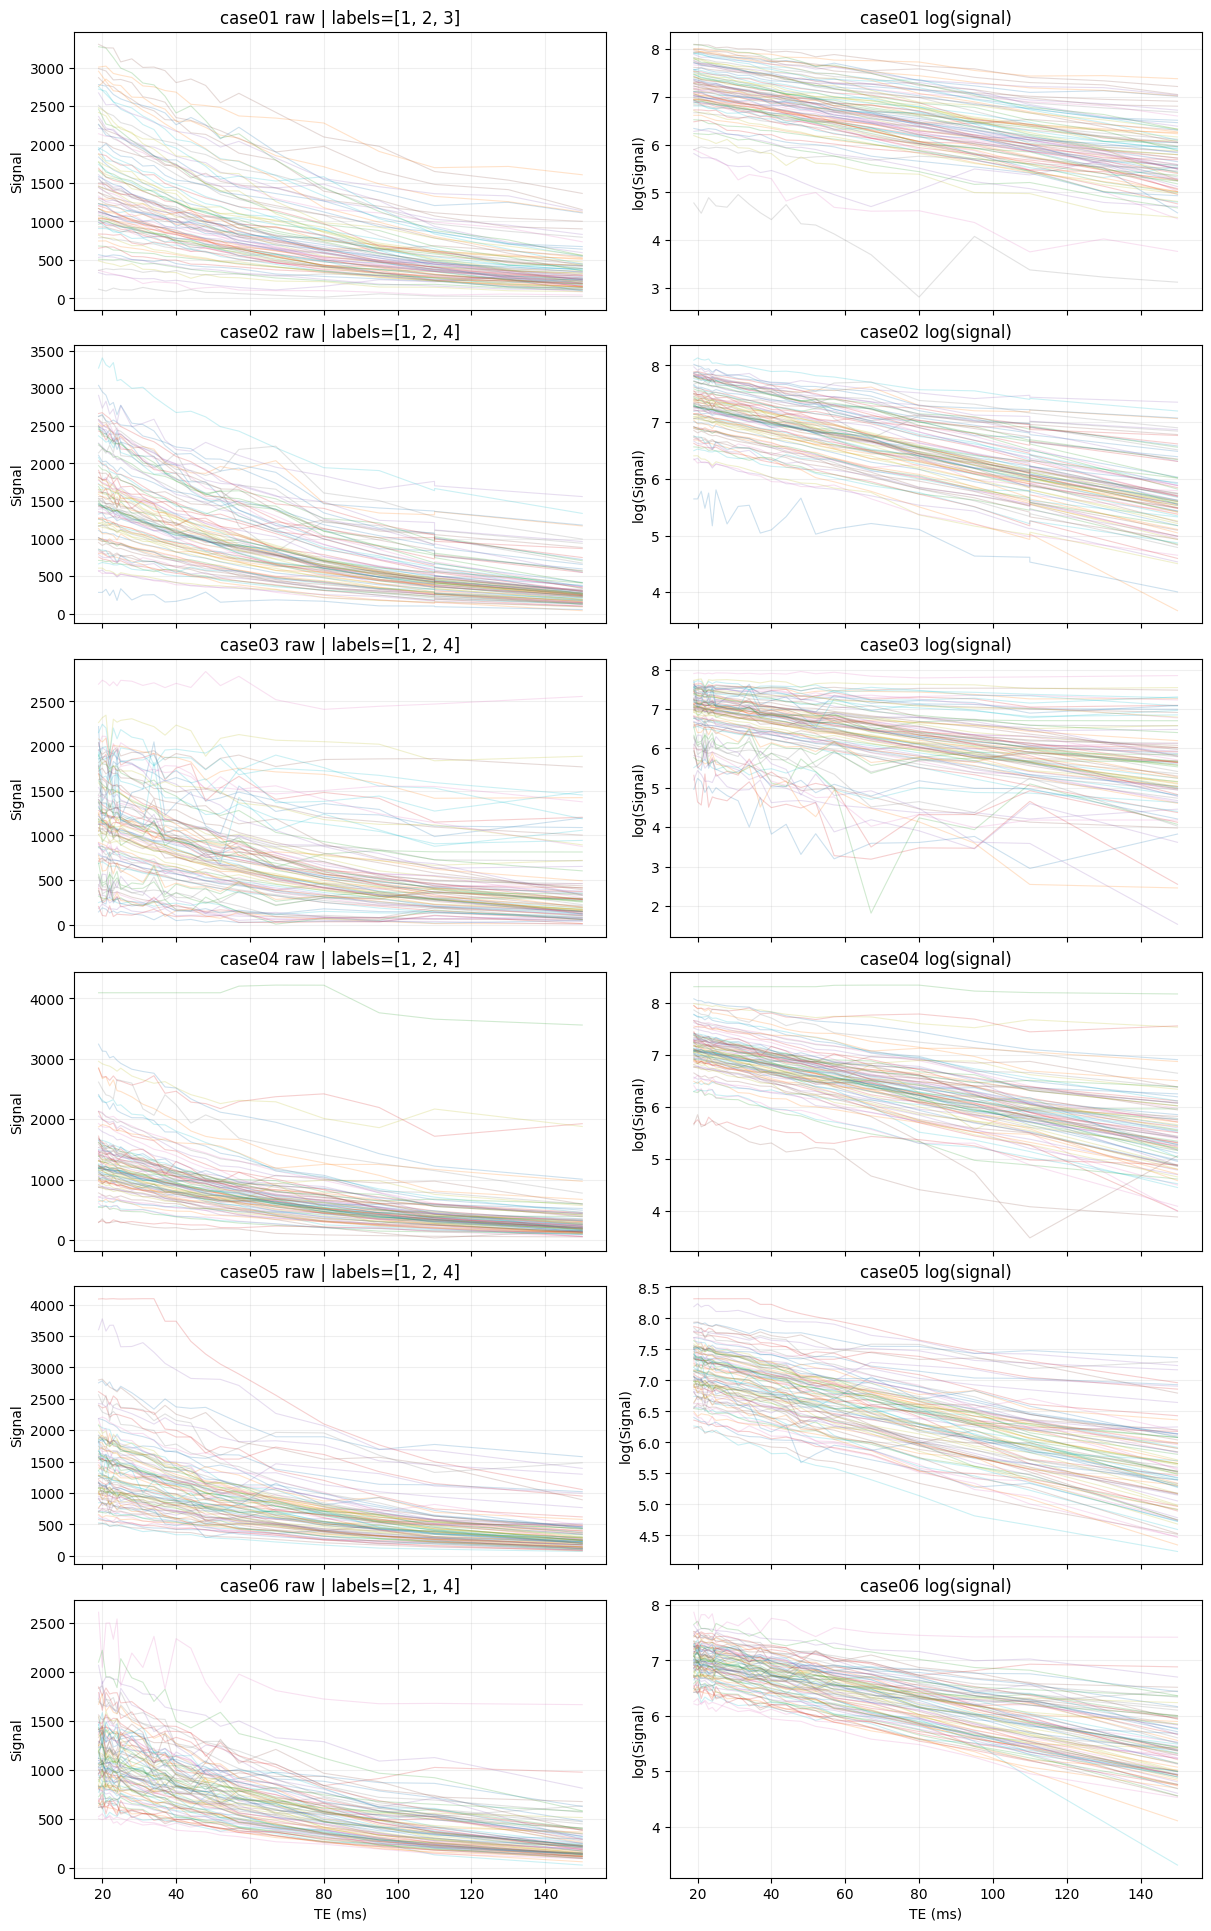

In [8]:
if curves_df.empty:
    raise RuntimeError('No ROI curves sampled. Check ROI maps and masks.')

n_cases = len(cases)
fig, axes = plt.subplots(n_cases, 2, figsize=(12, 3.2 * n_cases), constrained_layout=True, sharex='col')
if n_cases == 1:
    axes = np.array([axes])

for row, cp in enumerate(cases):
    case_id = cp.case_id
    sub = curves_df[curves_df['case_id'] == case_id]
    ax_raw, ax_log = axes[row, 0], axes[row, 1]

    if sub.empty:
        ax_raw.set_visible(False)
        ax_log.set_visible(False)
        continue

    for (_, _), grp in sub.groupby(['roi_label', 'roi_voxel_id']):
        ax_raw.plot(grp['te_ms'], grp['signal'], alpha=0.22, lw=0.8)
        ax_log.plot(grp['te_ms'], grp['log_signal'], alpha=0.22, lw=0.8)

    ax_raw.set_title(f"{case_id} raw | labels={selected_labels.get(case_id, [])}")
    ax_log.set_title(f"{case_id} log(signal)")
    ax_raw.set_ylabel('Signal')
    ax_log.set_ylabel('log(Signal)')
    ax_raw.grid(alpha=0.2)
    ax_log.grid(alpha=0.2)

axes[-1, 0].set_xlabel('TE (ms)')
axes[-1, 1].set_xlabel('TE (ms)')
fig.savefig(OUTPUT_DIR / 'sampled_roi_curves.png', dpi=180)
plt.show()


## 4) Assumption Metrics Summary

Per case metrics:
1. Monotonicity violation rate (`?S/S_prev > 5%`)
2. Early-echo monotonicity violation rate
3. Mono-exponential fit quality (`R^2` distribution)
4. Non-positive signal voxel rate
5. Echo-level anomaly count and transitions


In [9]:
metrics_rows = []
for cp in cases:
    c = case_data[cp.case_id]
    m = compute_qc_metrics(c['data'], c['mask'], c['tes'], thresholds=THRESHOLDS, seed=SEED)
    m['case_id'] = cp.case_id
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).sort_values('case_id').reset_index(drop=True)

summary_cols = [
    'case_id',
    'brain_voxels',
    'te_count',
    'te_duplicate_count',
    'mono_violation_rate_pct',
    'early_mono_violation_rate_pct',
    'r2_median',
    'r2_poor_rate_pct',
    'nonpositive_voxel_rate_pct',
    'echo_anomaly_count',
    'echo_anomaly_transitions',
]

metrics_df[summary_cols]


,case_id,brain_voxels,te_count,te_duplicate_count,mono_violation_rate_pct,early_mono_violation_rate_pct,r2_median,r2_poor_rate_pct,nonpositive_voxel_rate_pct,echo_anomaly_count,echo_anomaly_transitions
0,case01,109859,19,0,20.488080,12.954788,0.992663,15.68,0.024577,5,"67->80ms (-15.5%, z=-3.66); 80->95ms (-16.9%, ..."
1,case02,94789,22,1,45.816498,25.131608,0.994568,15.16,0.035869,4,"67->80ms (-16.0%, z=-2.79); 80->95ms (-17.7%, ..."
2,case03,61872,21,0,53.280967,49.240367,0.986772,27.78,0.819434,4,"67->80ms (-15.4%, z=-3.02); 80->95ms (-17.9%, ..."
3,case04,101592,21,0,26.501102,15.673478,0.989747,22.16,0.028546,4,"67->80ms (-16.6%, z=-2.87); 80->95ms (-17.8%, ..."
4,case05,104689,21,0,39.137827,31.749276,0.991604,18.50,0.042029,4,"67->80ms (-16.8%, z=-2.90); 80->95ms (-19.0%, ..."
5,case06,90702,21,0,57.551101,52.360477,0.988499,25.52,0.163172,4,"67->80ms (-16.3%, z=-2.99); 80->95ms (-18.2%, ..."


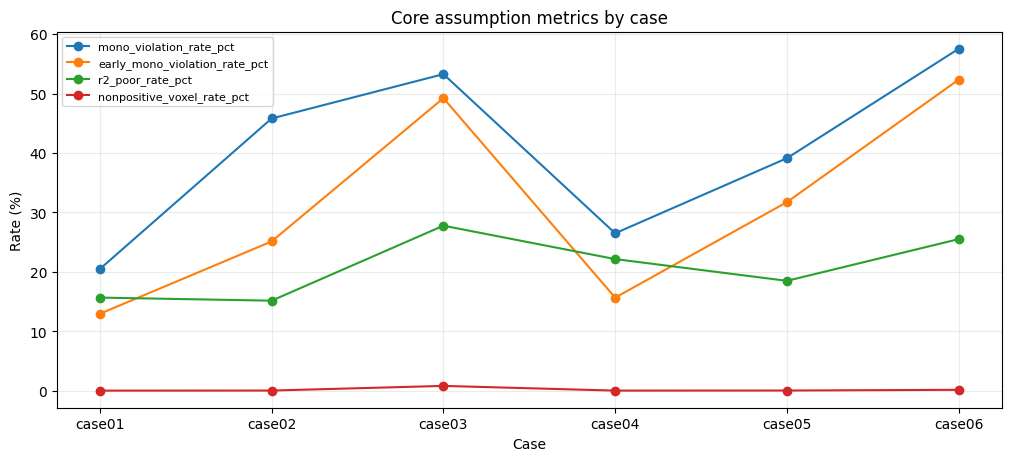

In [10]:
metrics_df.to_csv(OUTPUT_DIR / 'qc_metrics_summary.csv', index=False)

plot_cols = ['mono_violation_rate_pct', 'early_mono_violation_rate_pct', 'r2_poor_rate_pct', 'nonpositive_voxel_rate_pct']
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for col in plot_cols:
    ax.plot(metrics_df['case_id'], metrics_df[col], marker='o', lw=1.5, label=col)
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Case')
ax.set_title('Core assumption metrics by case')
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.savefig(OUTPUT_DIR / 'assumption_metrics_overview.png', dpi=180)
plt.show()


## 5) Distortion Interpretation

Map metrics to likely distortion factors and expected impact on downstream T2/S0 fitting.


In [11]:
reports = []
for _, row in metrics_df.iterrows():
    case_id = row['case_id']
    case_curves = curves_df[curves_df['case_id'] == case_id] if not curves_df.empty else None
    report = make_case_report(
        row.to_dict(),
        case_curves,
        figs={
            'global_decay': 'global_decay_curves.png',
            'echo_zscores': 'echo_transition_zscores.png',
            'roi_curves': 'sampled_roi_curves.png',
        },
    )
    reports.append(report)

report_rows = []
for r in reports:
    report_rows.append(
        {
            'case_id': r['case_id'],
            'risk_score': r['risk_score'],
            'risk_level': r['risk_level'],
            'key_distortion': r['key_distortions'][0],
            'fit_impact': r['fit_impacts'][0],
            'recommendation': r['recommendations'][0],
        }
    )

report_df = pd.DataFrame(report_rows).sort_values(['risk_score', 'case_id'], ascending=[False, True]).reset_index(drop=True)
display(report_df)


,case_id,risk_score,risk_level,key_distortion,fit_impact,recommendation
0,case03,0.489231,medium,Early-echo non-monotonic behavior.,"Suggests motion/registration mismatch, stimula...",Use robust loss and inspect short-TE outliers ...
1,case06,0.453412,medium,Early-echo non-monotonic behavior.,"Suggests motion/registration mismatch, stimula...",Use robust loss and inspect short-TE outliers ...
2,case02,0.428303,medium,TE schedule inconsistency (duplicate echo time).,Can destabilize slope-based estimates and over...,Deduplicate or merge repeated TEs before fitting.
3,case05,0.330314,medium,Early-echo non-monotonic behavior.,"Suggests motion/registration mismatch, stimula...",Use robust loss and inspect short-TE outliers ...
4,case04,0.268391,low,Echo-specific global anomalies.,May indicate acquisition instability affecting...,Evaluate excluding anomalous echoes in sensiti...
5,case01,0.228417,low,Echo-specific global anomalies.,May indicate acquisition instability affecting...,Evaluate excluding anomalous echoes in sensiti...


In [12]:
for r in reports:
    print(f"{r['case_id']} | risk={r['risk_level']} ({r['risk_score']:.3f})")
    print('  Distortions:')
    for d in r['key_distortions']:
        print('   -', d)
    print('  Expected fit impact:')
    for d in r['fit_impacts']:
        print('   -', d)
    print('  Recommendations:')
    for d in r['recommendations']:
        print('   -', d)


case01 | risk=low (0.228)
  Distortions:
   - Echo-specific global anomalies.
  Expected fit impact:
   - May indicate acquisition instability affecting specific TEs.
  Recommendations:
   - Evaluate excluding anomalous echoes in sensitivity analyses.
case02 | risk=medium (0.428)
  Distortions:
   - TE schedule inconsistency (duplicate echo time).
   - Echo-specific global anomalies.
  Expected fit impact:
   - Can destabilize slope-based estimates and overweight a repeated echo.
   - May indicate acquisition instability affecting specific TEs.
  Recommendations:
   - Deduplicate or merge repeated TEs before fitting.
   - Evaluate excluding anomalous echoes in sensitivity analyses.
case03 | risk=medium (0.489)
  Distortions:
   - Early-echo non-monotonic behavior.
   - Substantial mono-exponential misfit.
   - Non-positive signal in masked voxels.
   - Echo-specific global anomalies.
  Expected fit impact:
   - Suggests motion/registration mismatch, stimulated echoes, or multi-componen

## 6) Risk Ranking + Report-Ready Conclusion


In [13]:
ranking_df = summarize_case_reports(reports)
display(ranking_df)

ranking_df.to_csv(OUTPUT_DIR / 'case_risk_ranking.csv', index=False)
report_df.to_csv(OUTPUT_DIR / 'case_reports_table.csv', index=False)

high_cases = ranking_df.loc[ranking_df['risk_level'] == 'high', 'case_id'].tolist()
dup_cases = metrics_df.loc[metrics_df['te_duplicate_count'] > 0, 'case_id'].tolist()
worst_early = (
    metrics_df.sort_values('early_mono_violation_rate_pct', ascending=False)
    .head(2)['case_id']
    .tolist()
)

conclusion = (
    'Core task 1 conclusion: data quality differs across subjects. '
    f"Highest QC risk cases are {', '.join(high_cases) if high_cases else 'none'}. "
    f"Duplicate echo metadata was detected in {', '.join(dup_cases) if dup_cases else 'none'} (notably case02). "
    f"Strongest early-echo monotonicity violations were seen in {', '.join(worst_early)}. "
    'These effects can bias one-compartment T2/S0 estimation; downstream fitting should include '
    'echo-sensitivity analysis, robust/weighted fitting, and per-case QC-aware preprocessing.'
)

display(Markdown('**Conclusion paragraph (for coursework report):**'))
print(conclusion)

(OUTPUT_DIR / 'core_task1_conclusion.txt').write_text(conclusion, encoding='utf-8')


,case_id,risk_score,risk_level,top_distortion,top_recommendation
0,case03,0.489231,medium,Early-echo non-monotonic behavior.,Use robust loss and inspect short-TE outliers ...
1,case06,0.453412,medium,Early-echo non-monotonic behavior.,Use robust loss and inspect short-TE outliers ...
2,case02,0.428303,medium,TE schedule inconsistency (duplicate echo time).,Deduplicate or merge repeated TEs before fitting.
3,case05,0.330314,medium,Early-echo non-monotonic behavior.,Use robust loss and inspect short-TE outliers ...
4,case04,0.268391,low,Echo-specific global anomalies.,Evaluate excluding anomalous echoes in sensiti...
5,case01,0.228417,low,Echo-specific global anomalies.,Evaluate excluding anomalous echoes in sensiti...


**Conclusion paragraph (for coursework report):**

Core task 1 conclusion: data quality differs across subjects. Highest QC risk cases are none. Duplicate echo metadata was detected in case02 (notably case02). Strongest early-echo monotonicity violations were seen in case06, case03. These effects can bias one-compartment T2/S0 estimation; downstream fitting should include echo-sensitivity analysis, robust/weighted fitting, and per-case QC-aware preprocessing.


412

## 7) Synthetic Sanity Tests

Checks that QC metrics react in the expected direction on controlled synthetic data.


In [14]:
synthetic = run_synthetic_sanity_checks(seed=SEED, verbose=False)
synthetic_df = pd.DataFrame(
    [
        {
            'scenario': key,
            'mono_violation_rate_pct': value['mono_violation_rate_pct'],
            'early_mono_violation_rate_pct': value['early_mono_violation_rate_pct'],
            'r2_median': value['r2_median'],
            'r2_poor_rate_pct': value['r2_poor_rate_pct'],
            'te_duplicate_count': value['te_duplicate_count'],
        }
        for key, value in synthetic.items()
    ]
)
display(synthetic_df)
print('Synthetic sanity checks passed.')


,scenario,mono_violation_rate_pct,early_mono_violation_rate_pct,r2_median,r2_poor_rate_pct,te_duplicate_count
0,baseline,20.833333,0.000000,0.996961,0.000000,0
1,anomalous,76.000000,33.333333,0.985147,0.166667,0
2,anomalous_dup_te,76.000000,33.333333,0.984970,0.166667,1


Synthetic sanity checks passed.


## Deliverables Produced by This Notebook

Saved under `core_task1/outputs/`:
- `global_decay_curves.png`
- `echo_transition_zscores.png`
- `sampled_roi_curves.png`
- `assumption_metrics_overview.png`
- `qc_metrics_summary.csv`
- `case_risk_ranking.csv`
- `case_reports_table.csv`
- `core_task1_conclusion.txt`
